# P2 — Primera Red Densa: ML Clásico vs Keras

**Autor:** Carlos Tessier  
**Fecha:** Marzo 2026  
**Licencia:** [CC BY-NC 4.0](https://creativecommons.org/licenses/by-nc/4.0/) — Uso libre con atribución, sin fines comerciales.  

## Introducción

En los módulos de **Programación de IA** y **Sistemas de Aprendizaje Automático** no solo interesa usar modelos, sino entender cuándo tiene sentido aplicar una red neuronal y cuándo un modelo clásico ya ofrece un rendimiento muy competitivo. Este cuaderno plantea precisamente esa comparación en un problema real de clasificación binaria.

A lo largo de la práctica recorreremos un flujo completo de trabajo: exploración de datos, baseline clásico, red neuronal densa con Keras y comparación final. La idea no es solo entrenar modelos, sino desarrollar criterio para interpretar resultados y justificar decisiones.

## Objetivos de aprendizaje

- Analizar un problema tabular de clasificación binaria mediante un flujo básico de trabajo en IA.
- Realizar un EDA inicial y relacionar sus resultados con las decisiones posteriores de modelado.
- Entrenar modelos clásicos como baseline y usarlos como referencia para evaluar una red neuronal densa.
- Construir y entrenar una primera red densa con Keras, interpretando su arquitectura, entrenamiento y resultados.
- Comparar enfoques de ML clásico y redes neuronales para extraer conclusiones sobre cuándo compensa usar uno u otro.

## 1. Librerías necesarias

Antes de empezar, importamos todas las librerías que vamos a usar a lo largo del notebook. Es una buena práctica agruparlas todas al principio.

### ¿Qué es TensorFlow y Keras?

**TensorFlow** es una librería de código abierto desarrollada por Google para construir y entrenar modelos de aprendizaje automático, especialmente redes neuronales. Es una de las más utilizadas en la industria y la investigación.

**Keras** es la interfaz de alto nivel de TensorFlow. Piensa en ello así: TensorFlow es el motor potente pero complejo, y Keras es el volante y los pedales que te permiten conducirlo de forma sencilla. Con Keras podemos definir, entrenar y evaluar redes neuronales con pocas líneas de código.

### ¿Qué importamos?

- **numpy / pandas / matplotlib / seaborn**: las herramientas habituales de análisis y visualización.
- **sklearn**: para cargar el dataset, dividirlo en train/test, normalizar, y entrenar modelos clásicos de ML.
- **tensorflow / keras / layers**: el corazón del notebook. Con `keras.Sequential` construiremos la red neuronal, y con `layers.Dense` definiremos cada capa.

### Semillas aleatorias

Las líneas `np.random.seed(42)` y `tf.random.set_seed(42)` fijan las semillas del generador de números aleatorios. Esto garantiza que el experimento sea **reproducible**: si dos personas ejecutan el mismo código, obtendrán exactamente los mismos resultados.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, ConfusionMatrixDisplay)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)
os.makedirs('img', exist_ok=True)

print(f"TensorFlow: {tf.__version__}")
print(f"Keras: {keras.__version__}")

TensorFlow: 2.18.0
Keras: 3.8.0


## 2. Carga del dataset

Usamos el dataset **Breast Cancer Wisconsin**, uno de los más conocidos en clasificación binaria. Está incluido directamente en scikit-learn, por lo que no hace falta descargarlo.

### ¿Qué contiene?

- **569 muestras** de tumores de mama, cada una descrita por **30 características numéricas** calculadas a partir de imágenes de biopsias (radio, textura, perímetro, área, suavidad, etc.).
- La **etiqueta** (`y`) indica si el tumor es:
  - `0` → **Maligno** (canceroso)
  - `1` → **Benigno** (no canceroso)

### ¿Por qué es un buen dataset para aprender?

- Es pequeño y manejable (se entrena en segundos).
- Es un problema de **clasificación binaria** real con impacto médico.
- Permite comparar fácilmente ML clásico contra redes neuronales.
- Tiene cierto desbalance de clases (~37% maligno, ~63% benigno), lo que nos obliga a mirar más allá del accuracy.

In [10]:
# ============================================================
# Carga del dataset Breast Cancer Wisconsin
# ============================================================
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='diagnosis')  # 0=maligno, 1=benigno

print("=== Dataset Breast Cancer Wisconsin ===")
print(f"Muestras: {X.shape[0]}, Características: {X.shape[1]}")
print(f"\nDistribución de clases:")
print(y.value_counts().rename({0: 'Maligno', 1: 'Benigno'}))
print(f"\nPorcentaje maligno: {(y==0).mean()*100:.1f}%")

X.head()

=== Dataset Breast Cancer Wisconsin ===
Muestras: 569, Características: 30

Distribución de clases:
diagnosis
Benigno    357
Maligno    212
Name: count, dtype: int64

Porcentaje maligno: 37.3%


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 3. Análisis Exploratorio de Datos (EDA)

Antes de entrenar cualquier modelo, es imprescindible entender los datos. El EDA nos ayuda a detectar problemas (datos faltantes, outliers, correlaciones extremas) y a formarnos intuiciones sobre qué características serán útiles.

### ¿Qué visualizamos?

- **Mapa de calor de correlaciones**: muestra cómo se relacionan entre sí las características. Valores cercanos a 1 (rojo) indican alta correlación positiva; cercanos a -1 (azul), negativa. Si dos features están muy correlacionadas entre sí pero no con la etiqueta, una de ellas puede ser redundante.

- **Boxplot por clase**: compara la distribución de cada feature entre tumores malignos y benignos. Si las cajas de ambas clases se solapan poco, esa feature será muy discriminativa para el modelo.

> **Fíjate en:** ¿Las features como `mean radius` o `mean area` separan bien maligno de benigno? ¿Qué te dice eso sobre su utilidad para la clasificación?

Estadísticas descriptivas (primeras 5 features):
       mean radius  mean texture  mean perimeter  mean area  mean smoothness
count       569.00        569.00          569.00     569.00           569.00
mean         14.13         19.29           91.97     654.89             0.10
std           3.52          4.30           24.30     351.91             0.01
min           6.98          9.71           43.79     143.50             0.05
25%          11.70         16.17           75.17     420.30             0.09
50%          13.37         18.84           86.24     551.10             0.10
75%          15.78         21.80          104.10     782.70             0.11
max          28.11         39.28          188.50    2501.00             0.16


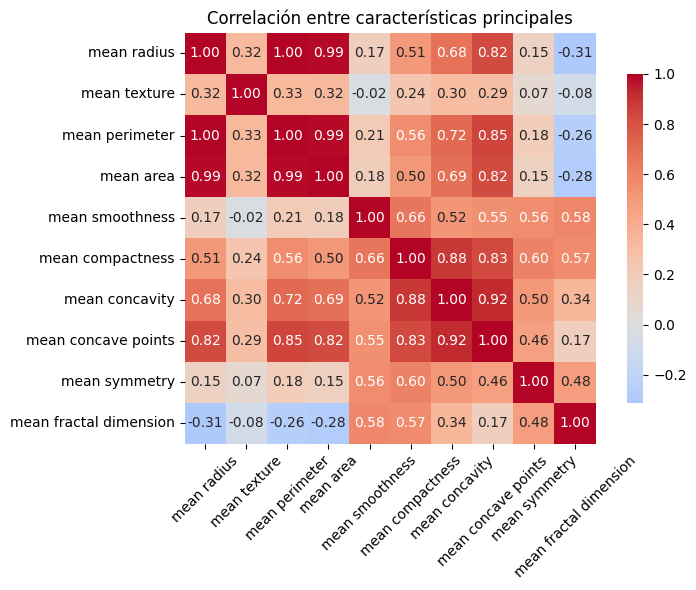

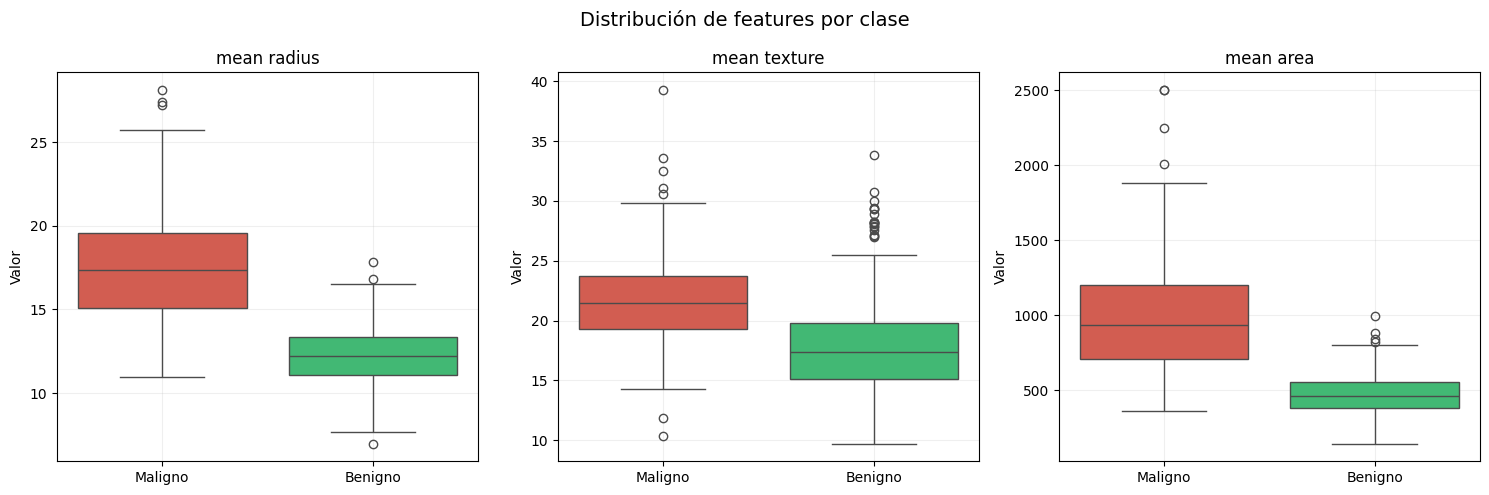

In [11]:
# ============================================================
# EDA: Estadísticas básicas y correlaciones
# ============================================================
print("Estadísticas descriptivas (primeras 5 features):")
print(X.iloc[:, :5].describe().round(2))

# Features principales
top_features = ['mean radius', 'mean texture', 'mean perimeter',
                'mean area', 'mean smoothness', 'mean compactness',
                'mean concavity', 'mean concave points', 'mean symmetry',
                'mean fractal dimension']

# ============================================================
# FIGURA 1: Heatmap de correlación
# ============================================================
plt.figure(figsize=(8, 6))

corr_matrix = X[top_features].corr()
sns.heatmap(corr_matrix, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', square=True,
            cbar_kws={'shrink': 0.8})

plt.title('Correlación entre características principales')
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('img/p2_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# FIGURA 2: Boxplots separados por feature (FIX seaborn warning)
# ============================================================
features_plot = ['mean radius', 'mean texture', 'mean area']

# Preparar datos
X_plot = X[features_plot].copy()
X_plot['Diagnóstico'] = y.map({0: 'Maligno', 1: 'Benigno'})

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, feature in enumerate(features_plot):
    sns.boxplot(
        data=X_plot,
        x='Diagnóstico',
        y=feature,
        hue='Diagnóstico',  # ✅ requerido por seaborn >= 0.13
        ax=axes[i],
        palette={'Maligno': '#e74c3c', 'Benigno': '#2ecc71'},
        legend=False        # ✅ evita duplicar leyenda
    )
    
    axes[i].set_title(feature)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Valor')
    axes[i].grid(True, alpha=0.2)

plt.suptitle('Distribución de features por clase', fontsize=14)
plt.tight_layout()

plt.savefig('img/p2_boxplots_separados.png', dpi=150, bbox_inches='tight')
plt.show()

### Qué deberías haber obtenido del EDA

En este punto lo importante no es solo ver estadísticas, sino extraer pistas para el modelado.

- Estamos ante un dataset tabular relativamente pequeño.
- Las variables son numéricas y ya sugieren que un modelo clásico puede funcionar bastante bien.
- Esto convierte a la red neuronal en una herramienta de comparación, no en una apuesta automática.

Una buena práctica profesional es justo esta: mirar primero los datos y solo después decidir qué modelo tiene sentido probar.

## 4. Preprocesado: división y normalización

Antes de entrenar cualquier modelo necesitamos preparar los datos de dos formas esenciales.

### 4.1 División train / test

Dividimos el dataset en dos subconjuntos:
- **Train (80%)**: el modelo aprende con estos datos.
- **Test (20%)**: datos que el modelo **nunca ha visto**, usados solo para evaluar el rendimiento final.

El parámetro `stratify=y` garantiza que la proporción de clases (maligno/benigno) sea la misma en train y test. Sin esto, podríamos tener mala suerte y que el conjunto de test tuviera muchos más casos de una clase.

### 4.2 Normalización con StandardScaler

Las 30 características del dataset tienen escalas muy distintas: el área puede valer miles, mientras que la suavidad vale décimas. Esto es un problema porque:
- Los modelos basados en distancias (como SVM) se ven muy afectados por las escalas.
- Las redes neuronales convergen mucho más lento con datos sin normalizar.

`StandardScaler` transforma cada feature para que tenga **media 0 y desviación estándar 1**:

$$x' = \frac{x - \mu}{\sigma}$$

> **Importante:** el scaler se ajusta **solo con los datos de train** (`fit_transform`) y luego se aplica a test (`transform`). Nunca al revés — si incluyéramos información de test en el ajuste, estaríamos haciendo "trampa" (data leakage).

In [12]:
# ============================================================
# Preprocesado: split y normalización
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y.values, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}")
print(f"Clases train — Maligno: {(y_train==0).sum()}, Benigno: {(y_train==1).sum()}")

Train: (455, 30), Test: (114, 30)
Clases train — Maligno: 170, Benigno: 285


### Por qué este preprocesado es importante

Aquí hacemos dos pasos básicos que aparecen una y otra vez en aprendizaje automático: separar train y test y escalar las variables.

- La separación evita evaluar el modelo con datos que ya ha visto.
- La normalización facilita el entrenamiento de la red y también beneficia a modelos como SVM.
- Si este paso se hace mal, la comparación entre modelos deja de ser fiable.


## 5. Modelos de ML clásico como baseline

Antes de construir una red neuronal, entrenamos modelos más sencillos. Esto se llama establecer un **baseline**: una referencia con la que comparar. Si nuestra red neuronal no supera al baseline, algo está mal (o simplemente no merece la pena).

### Modelos utilizados

**Regresión Logística** (`LogisticRegression`)  
A pesar del nombre, es un modelo de **clasificación**. Aprende una frontera de decisión lineal: calcula una combinación ponderada de las features y aplica la función sigmoide para obtener una probabilidad entre 0 y 1. Es simple, rápido e interpretable.

**SVM con kernel RBF** (`SVC(kernel='rbf')`)  
Support Vector Machine con kernel de función de base radial. Proyecta los datos a un espacio de mayor dimensión para encontrar una frontera de decisión no lineal. Suele dar muy buenos resultados en datasets pequeños y tabulares.

### ¿Por qué empezar por aquí?

En machine learning, la regla de oro es: **empieza simple**. Si un modelo sencillo ya resuelve bien el problema, no necesitas la complejidad de una red neuronal. Las redes neuronales brillan cuando los datos son muy grandes, no estructurados (imágenes, texto, audio) o cuando las relaciones son extremadamente complejas.

In [13]:
# ============================================================
# ML Clásico: Logistic Regression + SVM (baseline)
# ============================================================

# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
acc_lr = accuracy_score(y_test, y_pred_lr)

# SVM
svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)
acc_svm = accuracy_score(y_test, y_pred_svm)

print("=" * 50)
print(f"Logistic Regression — Accuracy: {acc_lr:.4f}")
print(classification_report(y_test, y_pred_lr, target_names=['Maligno', 'Benigno']))

print("=" * 50)
print(f"SVM — Accuracy: {acc_svm:.4f}")
print(classification_report(y_test, y_pred_svm, target_names=['Maligno', 'Benigno']))

Logistic Regression — Accuracy: 0.9825
              precision    recall  f1-score   support

     Maligno       0.98      0.98      0.98        42
     Benigno       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

SVM — Accuracy: 0.9825
              precision    recall  f1-score   support

     Maligno       0.98      0.98      0.98        42
     Benigno       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



### Qué aporta el baseline clásico

Antes de construir la red neuronal, conviene tener una referencia razonable. Logistic Regression y SVM no están aquí como relleno: sirven para responder a una pregunta clave del módulo.

**¿Aporta realmente algo una red neuronal en este problema, o un modelo clásico ya resuelve bien la tarea?**

## 6. Construcción de la red neuronal con Keras

Aquí es donde entra Keras. Vamos a construir una **red neuronal densa** (también llamada *fully connected* o *feedforward*). Analicemos cada parte en detalle.

### 6.1 ¿Qué es una neurona artificial?

Una neurona recibe varias entradas $x_1, x_2, \ldots, x_n$, les aplica unos pesos $w_1, w_2, \ldots, w_n$ (que aprende durante el entrenamiento), suma todo junto con un sesgo $b$, y pasa el resultado por una **función de activación**:

$$\text{salida} = f\left(\sum_{i=1}^{n} w_i \cdot x_i + b\right)$$

### 6.2 ¿Qué es una capa densa (`Dense`)?

Una capa densa es un grupo de neuronas donde **cada neurona está conectada a todas las entradas**. En Keras se define con:

```python
layers.Dense(64, activation='relu')
```

- `64` → número de neuronas en esta capa (cuántas unidades de procesamiento).
- `activation='relu'` → la función de activación que aplica cada neurona.

### 6.3 Funciones de activación

**ReLU** (*Rectified Linear Unit*) — `activation='relu'`  

$f(x) = \max(0, x)$ 

Devuelve 0 si la entrada es negativa, y la propia entrada si es positiva. Es la más usada en capas ocultas porque es simple, rápida y evita problemas de gradientes que desaparecen.

**Sigmoide** — `activation='sigmoid'`  

$f(x) = \frac{1}{1 + e^{-x}}$  

Aplasta cualquier valor al rango (0, 1), lo que la hace perfecta para la **capa de salida en clasificación binaria**: la salida se interpreta directamente como una probabilidad.

### 6.4 Arquitectura de nuestra red

<img src="img/red-neuronal.png" alt="red-neuronal" width="600"/>


Usamos `keras.Sequential` porque las capas se apilan una tras otra en secuencia, sin bifurcaciones.

### 6.5 Compilación del modelo

Después de definir la arquitectura, hay que **compilar** el modelo. Aquí se especifican tres cosas:

| Parámetro | Valor | ¿Qué hace? |
|---|---|---|
| `optimizer` | `'adam'` | Algoritmo que ajusta los pesos durante el entrenamiento |
| `loss` | `'binary_crossentropy'` | Función que mide el error del modelo (para clasificación binaria) |
| `metrics` | `['accuracy']` | Métricas que queremos monitorizar durante el entrenamiento |

> **Adam** (*Adaptive Moment Estimation*) es una versión avanzada del descenso de gradiente que ajusta automáticamente la tasa de aprendizaje para cada peso. Es el optimizador más usado por defecto.

> **Binary crossentropy** mide cuán lejos están las probabilidades predichas de las etiquetas reales. Cuanto más bajo, mejor.

### Qué esperamos de la primera red densa

Esta red es sencilla, pero suficiente para introducir varias ideas fundamentales:

- una capa de entrada conectada a capas ocultas densas;
- activaciones no lineales para aprender relaciones más complejas;
- y una salida `sigmoid` porque seguimos en un problema binario.

No buscamos la mejor arquitectura posible, sino una primera red que podamos entender, entrenar y comparar con criterio.

In [14]:
# ============================================================
# Red Neuronal Densa con Keras
# ============================================================

def construir_modelo(input_dim):
    """Construye una red densa simple."""
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')  # salida binaria
    ], name='red_densa_p2')
    
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

model = construir_modelo(X_train_scaled.shape[1])
model.summary()

2026-04-13 15:13:53.095924: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "red_densa_p2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Entrenamiento de la red neuronal

Con el modelo compilado, ya podemos entrenarlo. El entrenamiento es el proceso por el que la red **ajusta sus pesos** para minimizar el error. Se hace con el método `model.fit()`.

### 7.1 ¿Qué ocurre durante el entrenamiento?

El proceso se repite para cada **época**:

1. Se pasan los datos de entrenamiento en pequeños grupos llamados **batches**.
2. Para cada batch, la red hace una predicción (*forward pass*).
3. Se calcula el error con la función de pérdida (`binary_crossentropy`).
4. Se calcula el gradiente del error respecto a cada peso (*backpropagation*).
5. El optimizador (Adam) actualiza los pesos para reducir el error.

Después de procesar todos los batches, termina una época y empieza la siguiente.

### 7.2 Hiperparámetros del entrenamiento

Estos son los **hiperparámetros**: parámetros que nosotros elegimos antes de entrenar y que controlan cómo aprende la red. A diferencia de los pesos (que aprende el modelo), los hiperparámetros los fijamos nosotros.

| Hiperparámetro | Valor | Significado |
|---|---|---|
| `epochs` | `100` | Número de veces que la red ve el dataset completo. Más épocas = más aprendizaje, pero también riesgo de sobreajuste. |
| `batch_size` | `32` | Número de muestras que se procesan juntas antes de actualizar los pesos. Valores pequeños = más ruido pero mejor generalización; valores grandes = más estable pero más lento de converger. |
| `validation_split` | `0.2` | El 20% de los datos de train se reserva para **validación**: en cada época se evalúa el modelo sobre estos datos sin entrenar con ellos. Permite detectar sobreajuste a tiempo. |
| `verbose` | `0` | Controla cuánta información se muestra por pantalla. `0` = silencioso, `1` = barra de progreso, `2` = una línea por época. |

### 7.3 ¿Qué son las curvas de entrenamiento?

El objeto `history` guarda la evolución del error y el accuracy en cada época, tanto en train como en validación. Representarlas es esencial:

- Si **train loss baja pero val loss sube** → la red está memorizando los datos de train y no generaliza: **sobreajuste** (*overfitting*).
- Si **ambas curvas bajan juntas** → la red está aprendiendo correctamente.
- Si **ambas curvas se estancan pronto** → la red puede necesitar más capacidad (más capas/neuronas) o más épocas.

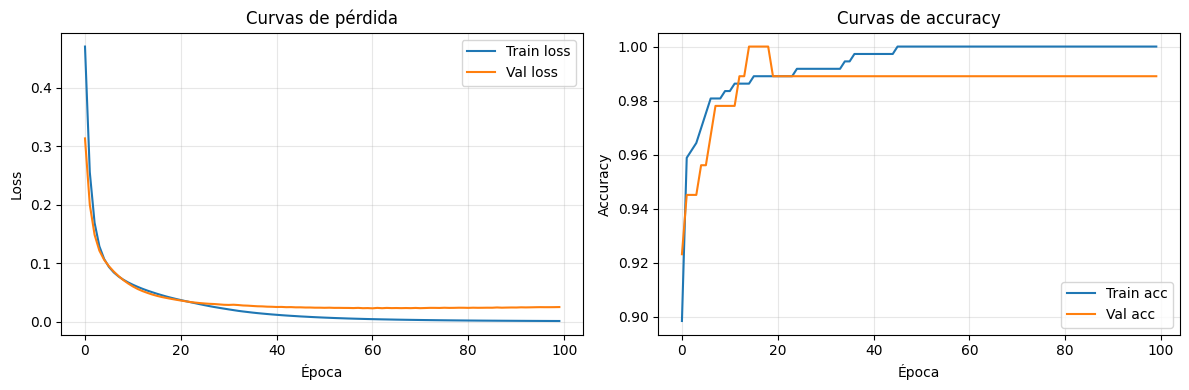


Red Neuronal — Accuracy en test: 0.9561
              precision    recall  f1-score   support

     Maligno       0.91      0.98      0.94        42
     Benigno       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [15]:
# Entrenamiento
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

# Curvas de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Train loss')
axes[0].plot(history.history['val_loss'], label='Val loss')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].set_title('Curvas de pérdida')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Train acc')
axes[1].plot(history.history['val_accuracy'], label='Val acc')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Curvas de accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('img/p2_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Evaluación en test
loss, acc_nn = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nRed Neuronal — Accuracy en test: {acc_nn:.4f}")
y_pred_nn = (model.predict(X_test_scaled, verbose=0) > 0.5).astype(int).flatten()
print(classification_report(y_test, y_pred_nn, target_names=['Maligno', 'Benigno']))

### Cómo leer el entrenamiento

Después de entrenar no basta con mirar el accuracy final. Las curvas ayudan a responder si la red está aprendiendo de forma útil o si empieza a memorizar.

- Si la pérdida de entrenamiento baja y la de validación también, la señal suele ser buena.
- Si se separan demasiado, puede haber sobreajuste.
- En datasets pequeños, estas diferencias deben interpretarse con prudencia.


### Qué nos dicen las curvas

Estas gráficas son una primera ventana al comportamiento interno del entrenamiento. No te quedes solo con cuál llega más abajo: intenta fijarte también en la estabilidad y en la distancia entre entrenamiento y validación.


## 8. Comparación de modelos

Llegamos a la fase final: comparar el rendimiento de los tres modelos sobre el conjunto de **test**, datos que ninguno ha visto durante el entrenamiento.

### Matrices de confusión

Una **matriz de confusión** muestra de forma visual los aciertos y errores del modelo para cada clase:

|  | Predicho: Maligno | Predicho: Benigno |
|---|---|---|
| **Real: Maligno** | Verdadero Positivo (TP) | Falso Negativo (FN) |
| **Real: Benigno** | Falso Positivo (FP) | Verdadero Negativo (TN) |

En un contexto médico como éste, los **Falsos Negativos** (decir que un tumor maligno es benigno) son mucho más peligrosos que los Falsos Positivos. El accuracy no lo captura, pero la matriz de confusión sí.

### ¿Por qué comparar los tres modelos?

Este ejercicio ilustra algo muy importante: **una red neuronal no siempre gana**. En datasets pequeños y tabulares como éste, los modelos clásicos son altamente competitivos. La red neuronal tiene más parámetros y necesita más datos para aprovechar toda su capacidad.

Fíjate en los resultados: ¿merece la pena la complejidad adicional de la red neuronal en este caso?

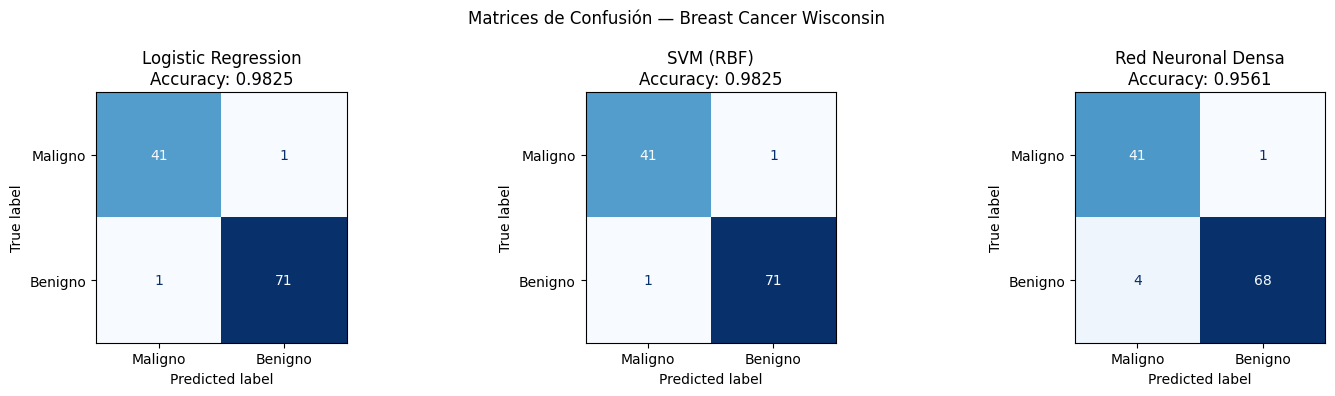


=== RESUMEN COMPARATIVO ===
             Modelo Accuracy Parámetros
Logistic Regression   0.9825         30
          SVM (RBF)   0.9825 RBF kernel
 Red Neuronal Densa   0.9561       4097


In [16]:
# ============================================================
# Comparación visual: matrices de confusión
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
modelos = [
    ('Logistic Regression', y_pred_lr, acc_lr),
    ('SVM (RBF)', y_pred_svm, acc_svm),
    ('Red Neuronal Densa', y_pred_nn, acc_nn),
]

for ax, (nombre, y_pred, acc) in zip(axes, modelos):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Maligno', 'Benigno'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{nombre}\nAccuracy: {acc:.4f}')

plt.suptitle('Matrices de Confusión — Breast Cancer Wisconsin', fontsize=12)
plt.tight_layout()
plt.savefig('img/p2_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabla resumen
resultados = pd.DataFrame({
    'Modelo': ['Logistic Regression', 'SVM (RBF)', 'Red Neuronal Densa'],
    'Accuracy': [f'{acc_lr:.4f}', f'{acc_svm:.4f}', f'{acc_nn:.4f}'],
    'Parámetros': [lr.n_features_in_, 'RBF kernel', model.count_params()]
})
print("\n=== RESUMEN COMPARATIVO ===")
print(resultados.to_string(index=False))

### Cómo interpretar la comparación final

La comparación entre modelos no consiste solo en ver quién gana por unas décimas. También hay que pensar qué tipo de problema tenemos delante.

- Si Logistic Regression rinde casi igual que la red, eso ya es una conclusión valiosa.
- Si la red mejora poco, quizá la complejidad extra no compense.
- Elegir modelo con criterio también forma parte del trabajo en IA.


## 🛠 Ejercicio

Modifica la arquitectura de la red neuronal y compara los resultados con el baseline de ML clásico:

1. **Arquitectura más profunda:** Añade más capas ocultas (e.g., 128 → 64 → 32 → 16). ¿Mejora el accuracy en test?

2. **Diferentes activaciones:** Prueba `tanh` en lugar de `relu`. ¿Qué diferencia observas en las curvas de entrenamiento?

3. **Más épocas:** Entrena con 200 épocas. ¿Qué ocurre en las curvas de val_loss?

4. **Tabla comparativa:** Crea un DataFrame con los resultados de todas las configuraciones probadas.

In [17]:
# Tu código aquí


## 💬 Reflexión

> **Pregunta 1:** En este dataset, Logistic Regression obtiene resultados muy competitivos con la red neuronal. ¿Por qué crees que ocurre esto? ¿Qué características del dataset lo favorecen?
>
> **Pregunta 2:** 
¿Cuándo merece la pena usar una red neuronal en lugar de ML clásico? Lista al menos 3 condiciones.
>
> **Pregunta 3:** La red neuronal tiene miles de parámetros para un dataset de ~500 muestras. ¿Es esto un problema? ¿Qué riesgo conlleva?

## Conclusión

En este cuaderno hemos construido una primera red densa y la hemos comparado con modelos clásicos sobre un problema real de clasificación binaria.

**Lo que hemos aprendido:**

- Un flujo completo de trabajo en IA incluye EDA, preprocesado, baseline, entrenamiento y comparación final.
- Una red neuronal no sustituye automáticamente a los modelos clásicos: hay problemas tabulares donde Logistic Regression o SVM siguen siendo muy competitivos.
- Las curvas de entrenamiento y las matrices de confusión ayudan a interpretar el comportamiento del modelo, no solo su resultado numérico.
- Evaluar con criterio significa relacionar el rendimiento con el tipo de datos, el tamaño del dataset y la complejidad del modelo.

**Relación con cuadernos anteriores:**

En **P0** y **P1** vimos cómo aprende una red y qué papel juega el gradiente descendente. Aquí damos el paso a una red densa real aplicada a un problema clásico de clasificación.

**Relación con cuadernos posteriores:**

Más adelante veremos casos donde las redes neuronales muestran más claramente su ventaja: datos más complejos, tareas menos lineales y dominios como visión o NLP. Este cuaderno sirve como referencia para entender cuándo esa ventaja aparece de verdad.

> **Siguiente paso:** En los próximos cuadernos ampliaremos estas ideas hacia arquitecturas y problemas donde la capacidad de representación de la red neuronal será más determinante.